In [1]:
!nvidia-smi

Sat Apr 11 02:34:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060        Off |   00000000:3B:00.0 Off |                  N/A |
|  0%   49C    P8             15W /  170W |      32MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from __future__ import annotations

import json
import platform
import random
from pathlib import Path
import numpy as np



# Notebook ini berjalan di Jupyter server terpisah, jadi tidak mengandalkan struktur repo lokal.
WORKDIR = Path.cwd()
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---- Execution switches ----
QUICK_DEBUG_MODE = True
RUN_STAGE1_VLM = True
ALLOW_STAGE1_FALLBACK = True
RUN_ABLATION = True

# Jika ingin pakai data Anda sendiri dari Jupyter server, ubah flag ini ke True.
USE_USER_DATA = False
USER_ANNOTATION_PATH = WORKDIR / "data" / "annotations.jsonl"
USER_IMAGE_ROOT = WORKDIR / "data" / "images"
USER_DATASET_NAME = "caer-s"  # atau "emotic"

# ---- Local VLM (2-4B class) settings ----

# Default: InstructBLIP FLAN-T5-XL (~3B class)
LOCAL_VLM_MODEL_ID = "Salesforce/instructblip-flan-t5-xl"

# Jika model sudah Anda download lokal, isi path ini agar offline sepenuhnya.
LOCAL_VLM_MODEL_PATH = WORKDIR / "local_models" / "instructblip-flan-t5-xl"
LOCAL_VLM_MAX_NEW_TOKENS = 96
LOCAL_VLM_SAMPLE_LIMIT = 12 if QUICK_DEBUG_MODE else None

# Versi dependency VLM yang kompatibel dengan kernel ini.
LOCAL_VLM_TRANSFORMERS_VERSION = "4.40.2"
LOCAL_VLM_ACCELERATE_VERSION = "0.28.0"
FORCE_VLM_BOOTSTRAP = False

# ---- Dataset bundle for next import ----
DATASET_BUNDLE_DIR = WORKDIR / "notebook_data" / "prepared_bundle"

print(f"WORKDIR: {WORKDIR}")
print(f"Python: {platform.python_version()}")
print(f"QUICK_DEBUG_MODE={QUICK_DEBUG_MODE}")
print(f"RUN_STAGE1_VLM={RUN_STAGE1_VLM}, ALLOW_STAGE1_FALLBACK={ALLOW_STAGE1_FALLBACK}, RUN_ABLATION={RUN_ABLATION}")
print(f"LOCAL_VLM_MODEL_ID={LOCAL_VLM_MODEL_ID}")
print(f"FORCE_VLM_BOOTSTRAP={FORCE_VLM_BOOTSTRAP}")

WORKDIR: /home/agung/riset
Python: 3.13.12
QUICK_DEBUG_MODE=True
RUN_STAGE1_VLM=True, ALLOW_STAGE1_FALLBACK=True, RUN_ABLATION=True
LOCAL_VLM_MODEL_ID=Salesforce/instructblip-flan-t5-xl
FORCE_VLM_BOOTSTRAP=False


In [3]:
import importlib
import sys

local_pkg_dir = WORKDIR / "_pylibs"
if local_pkg_dir.exists() and str(local_pkg_dir) not in sys.path:
    sys.path.append(str(local_pkg_dir))
    print("Added local package path:", local_pkg_dir)

# Dependency ringan untuk pipeline utama.
required_imports = {
    "torch": "torch",
    "torchvision": "torchvision",
    "numpy": "numpy",
    "pandas": "pandas",
    "PIL": "Pillow",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm"
}



# Dependency tambahan untuk Stage 1 local VLM 2-4B.
vlm_optional_imports = {
    "transformers": "transformers",
    "accelerate": "accelerate"
}

missing_required = [pkg for mod, pkg in required_imports.items() if importlib.util.find_spec(mod) is None]
missing_vlm = [pkg for mod, pkg in vlm_optional_imports.items() if importlib.util.find_spec(mod) is None]

print("Missing required packages:", missing_required if missing_required else "None")
print("Missing VLM packages:", missing_vlm if missing_vlm else "None")

import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

Missing required packages: None
Missing VLM packages: None
Torch version: 2.6.0+cu124
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060


In [4]:
if missing_required:
    raise RuntimeError(
        "Missing required packages: " + ", ".join(missing_required) +
        ". Silakan instal lewat environment manager server Anda, lalu jalankan ulang notebook."
    )

if RUN_STAGE1_VLM and missing_vlm:
    msg = "Stage 1 local VLM membutuhkan package: " + ", ".join(missing_vlm) + "."
    if ALLOW_STAGE1_FALLBACK:
        print(msg, "Notebook akan mencoba bootstrap lokal di cell berikut, lalu fallback jika tetap gagal.")
    else:
        raise RuntimeError(msg + " Set ALLOW_STAGE1_FALLBACK=True bila ingin lanjut dengan fallback.")

print("Environment check passed.")

Environment check passed.


## Optional VLM Bootstrap (Local User Space)



Jika package VLM belum tersedia, cell berikut mencoba install ke folder lokal notebook agar tidak butuh izin admin.

In [5]:
import importlib
import shutil
import subprocess
import sys

need_bootstrap = RUN_STAGE1_VLM and (bool(missing_vlm) or FORCE_VLM_BOOTSTRAP)

if need_bootstrap:
    local_pkg_dir = WORKDIR / "_pylibs"
    if local_pkg_dir.exists():
        shutil.rmtree(local_pkg_dir)
    local_pkg_dir.mkdir(parents=True, exist_ok=True)

    if str(local_pkg_dir) in sys.path:
        sys.path.remove(str(local_pkg_dir))
    sys.path.append(str(local_pkg_dir))

    install_pkgs = [
        f"transformers=={LOCAL_VLM_TRANSFORMERS_VERSION}",
        f"accelerate=={LOCAL_VLM_ACCELERATE_VERSION}",
        "huggingface-hub==0.23.4",
        "tokenizers==0.19.1",
        "safetensors==0.4.3",
        "sentencepiece==0.2.0",
        "regex==2024.5.15",
        "packaging==24.1",
        "filelock==3.15.4",
        "requests==2.32.3",
        "pyyaml==6.0.1",
        "tqdm==4.66.4",
        "typing-extensions==4.12.2",
        "numpy==1.26.4"
    ]



    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--no-deps",
        "--target",
        str(local_pkg_dir),
        *install_pkgs
    ]

    print("Installing VLM dependencies to:", local_pkg_dir)

    print("Command:", " ".join(cmd))

    try:

        subprocess.check_call(cmd)

    except Exception as exc:

        print("Local VLM bootstrap failed:", exc)



    importlib.invalidate_caches()

    missing_vlm = [pkg for mod, pkg in vlm_optional_imports.items() if importlib.util.find_spec(mod) is None]

    print("Remaining missing VLM packages:", missing_vlm if missing_vlm else "None")

    print("Jika sebelumnya transformers sudah ter-import, restart kernel sebelum lanjut.")

else:

    print("Bootstrap skipped (either RUN_STAGE1_VLM=False and no forced bootstrap).")

Bootstrap skipped (either RUN_STAGE1_VLM=False and no forced bootstrap).


In [6]:
import traceback



try:

    import transformers

    print("Transformers version:", transformers.__version__)

    print("Transformers path:", transformers.__file__)

    from transformers import AutoProcessor

    print("AutoProcessor import: OK")

except Exception as exc:

    print("Transformers import check failed:", exc)

    traceback.print_exc()

/home/agung/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers version: 5.5.3
Transformers path: /home/agung/miniconda3/lib/python3.13/site-packages/transformers/__init__.py
AutoProcessor import: OK


## Real Dataset Loader (Kaggle CAER-S)

Cell ini mengunduh dataset CAER-S dari Kaggle, mengekstrak file, membangun annotation JSONL (`image_path`, `labels`, `split`), lalu mengaktifkan mode `USE_USER_DATA=True`.

Catatan keamanan: kredensial Kaggle diset di runtime kernel, bukan disimpan permanen ke file konfigurasi eksternal.

In [22]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

# Gunakan dataset lokal hasil download terbaru.
LOCAL_CAERS_ROOT = WORKDIR / "caer_dataset" / "CAER-S"
KAGGLE_ANNOTATION_PATH = WORKDIR / "data" / "caers_kaggle" / "caers_annotations.jsonl"

if not LOCAL_CAERS_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset lokal tidak ditemukan di {LOCAL_CAERS_ROOT}. Jalankan dulu: python download_caers_dataset.py"
    )

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def build_caers_annotations_from_local(root: Path) -> list[dict]:
    records = []
    for split in ["train", "val", "test"]:
        split_dir = root / split
        if not split_dir.exists():
            continue

        for label_dir in sorted(split_dir.iterdir()):
            if not label_dir.is_dir():
                continue
            label_name = label_dir.name

            for img_path in sorted(label_dir.rglob("*")):
                if not img_path.is_file() or img_path.suffix.lower() not in IMAGE_EXTS:
                    continue

                rel = img_path.relative_to(root).as_posix()
                records.append(
                    {
                        "sample_id": rel.replace("/", "_"),
                        "image_path": rel,
                        "labels": label_name,
                        "split": split,
                    }
                )

    if not records:
        raise RuntimeError(f"Tidak ada gambar valid di {root}.")

    return records


def ensure_validation_split(
    records: list[dict], val_ratio: float = 0.1, min_val_per_class: int = 1, seed: int = 42
) -> tuple[list[dict], bool, dict]:
    split_counts = Counter(str(r.get("split", "")).lower() for r in records)
    if split_counts.get("val", 0) > 0:
        return records, False, {"moved_to_val": 0, "reason": "val_already_exists"}

    train_by_label: dict[str, list[int]] = defaultdict(list)
    for idx, rec in enumerate(records):
        if str(rec.get("split", "")).lower() == "train":
            train_by_label[str(rec.get("labels", "unknown"))].append(idx)

    rng = random.Random(seed)
    val_indices = set()
    for label, indices in sorted(train_by_label.items()):
        if len(indices) <= 1:
            # Sisakan minimal 1 sampel train untuk label ini.
            continue

        shuffled = indices[:]
        rng.shuffle(shuffled)

        n_val = max(min_val_per_class, int(round(len(shuffled) * val_ratio)))
        n_val = min(n_val, len(shuffled) - 1)
        val_indices.update(shuffled[:n_val])

    if not val_indices:
        return records, False, {"moved_to_val": 0, "reason": "insufficient_train_samples"}

    updated = []
    for idx, rec in enumerate(records):
        new_rec = dict(rec)
        if idx in val_indices and str(new_rec.get("split", "")).lower() == "train":
            new_rec["split"] = "val"
        updated.append(new_rec)

    return (
        updated,
        True,
        {
            "moved_to_val": len(val_indices),
            "classes_with_train": len(train_by_label),
            "val_ratio": val_ratio,
        },
    )


def write_jsonl(path: Path, records: list[dict]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for rec in records:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")


records_real = build_caers_annotations_from_local(LOCAL_CAERS_ROOT)
records_real, val_created, val_info = ensure_validation_split(records_real, val_ratio=0.1, seed=SEED)
write_jsonl(KAGGLE_ANNOTATION_PATH, records_real)

USE_USER_DATA = True
USER_ANNOTATION_PATH = KAGGLE_ANNOTATION_PATH
USER_IMAGE_ROOT = LOCAL_CAERS_ROOT
USER_DATASET_NAME = "caer-s"

print("Local dataset activated.")
print("USER_ANNOTATION_PATH:", USER_ANNOTATION_PATH)
print("USER_IMAGE_ROOT:", USER_IMAGE_ROOT)
print("USER_DATASET_NAME:", USER_DATASET_NAME)
print("Total parsed records:", len(records_real))
print("Split counts:", Counter([r["split"] for r in records_real]))
print("Label counts (top 10):", Counter([r["labels"] for r in records_real]).most_common(10))
if val_created:
    print("Auto validation split created from train:", val_info)
else:
    print("Validation split status:", val_info)

Local dataset activated.
USER_ANNOTATION_PATH: /home/agung/riset/data/caers_kaggle/caers_annotations.jsonl
USER_IMAGE_ROOT: /home/agung/riset/caer_dataset/CAER-S
USER_DATASET_NAME: caer-s
Total parsed records: 69999
Split counts: Counter({'train': 44107, 'test': 20992, 'val': 4900})
Label counts (top 10): [('Disgust', 10000), ('Fear', 10000), ('Happy', 10000), ('Neutral', 10000), ('Sad', 10000), ('Surprise', 9999), ('Angry', 7001), ('Anger', 2999)]
Auto validation split created from train: {'moved_to_val': 4900, 'classes_with_train': 7, 'val_ratio': 0.1}


## Dataset Setup and Integrity Checks (Server-Only)



Bagian ini tidak memakai modul repo.

- Jika USE_USER_DATA=False: buat dataset sintetis CAER-S kecil untuk debug cepat.

- Jika USE_USER_DATA=True: gunakan annotation dan image root dari path Jupyter server Anda.

In [8]:
from collections import Counter

from PIL import Image, ImageDraw



CAER_S_CLASSES = ["Anger", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]



def read_records(path: Path) -> list[dict]:

    path = Path(path)

    if path.suffix.lower() == ".jsonl":

        rows = []

        with path.open("r", encoding="utf-8") as f:

            for line in f:

                line = line.strip()

                if line:

                    rows.append(json.loads(line))

        return rows

    if path.suffix.lower() == ".json":

        with path.open("r", encoding="utf-8") as f:

            payload = json.load(f)

        return payload if isinstance(payload, list) else payload.get("records", [])

    raise ValueError(f"Unsupported annotation file format: {path}")



def write_jsonl(path: Path, records: list[dict]) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    with path.open("w", encoding="utf-8") as f:

        for rec in records:

            f.write(json.dumps(rec, ensure_ascii=False) + "\n")



def create_synthetic_caers_dataset(base_dir: Path, n_per_class: int = 8) -> tuple[Path, Path]:

    data_dir = base_dir / "notebook_data" / "caers_synth"

    image_root = data_dir / "images"

    image_root.mkdir(parents=True, exist_ok=True)



    records = []

    idx = 0

    for class_name in CAER_S_CLASSES:

        for i in range(n_per_class):

            img = Image.new("RGB", (128, 128), color=(30 + i * 3, 70 + i * 5, 120 + i * 2))

            draw = ImageDraw.Draw(img)

            draw.rectangle((10, 10, 118, 118), outline=(255, 255, 255), width=2)

            draw.text((14, 52), class_name, fill=(255, 220, 120))



            rel_path = Path("images") / f"{class_name.lower()}_{idx:04d}.png"

            abs_path = data_dir / rel_path

            abs_path.parent.mkdir(parents=True, exist_ok=True)

            img.save(abs_path)



            if i < n_per_class - 2:

                split = "train"

            elif i == n_per_class - 2:

                split = "val"

            else:

                split = "test"



            records.append({

                "sample_id": f"syn_{idx:05d}",

                "image_path": str(rel_path).replace("\\", "/"),

                "labels": class_name,

                "split": split,

                "bbox": [10, 10, 118, 118]

            })

            idx += 1



    ann_path = data_dir / "annotations.jsonl"

    write_jsonl(ann_path, records)

    return ann_path, data_dir



if USE_USER_DATA:

    annotation_path = Path(USER_ANNOTATION_PATH)

    image_root = Path(USER_IMAGE_ROOT)

    dataset_name = USER_DATASET_NAME

    task_type = "singlelabel" if dataset_name.lower() in {"caer-s", "caers"} else "multilabel"

else:

    annotation_path, image_root = create_synthetic_caers_dataset(WORKDIR, n_per_class=10 if QUICK_DEBUG_MODE else 30)

    dataset_name = "caer-s"

    task_type = "singlelabel"



records_preview = read_records(annotation_path)

print("Annotation path:", annotation_path)

print("Image root:", image_root)

print("Total records:", len(records_preview))

print("Split counts:", Counter([r.get("split", "") for r in records_preview]))

print("Dataset:", dataset_name, "| Task:", task_type)

Annotation path: /home/agung/riset/data/caers_kaggle/caers_annotations.jsonl
Image root: /home/agung/riset/caer_dataset/CAER-S
Total records: 69999
Split counts: Counter({'train': 49007, 'test': 20992})
Dataset: caer-s | Task: singlelabel


In [24]:
# Override reader: robust untuk JSONL yang kadang memiliki >1 objek JSON per baris.
def read_records(path: Path) -> list[dict]:
    path = Path(path)

    if path.suffix.lower() == ".jsonl":
        rows: list[dict] = []
        decoder = json.JSONDecoder()

        with path.open("r", encoding="utf-8") as f:
            for line_no, raw_line in enumerate(f, start=1):
                line = raw_line.strip()
                if not line:
                    continue

                # Normal case: 1 JSON object per line.
                try:
                    obj = json.loads(line)
                    if isinstance(obj, dict):
                        rows.append(obj)
                    continue
                except json.JSONDecodeError:
                    pass

                # Fallback: parse multiple JSON objects concatenated in one line.
                idx = 0
                parsed_any = False
                while idx < len(line):
                    while idx < len(line) and line[idx].isspace():
                        idx += 1
                    if idx >= len(line):
                        break

                    try:
                        obj, end = decoder.raw_decode(line, idx)
                    except json.JSONDecodeError:
                        break

                    if isinstance(obj, dict):
                        rows.append(obj)
                        parsed_any = True
                    idx = end

                if not parsed_any:
                    raise ValueError(
                        f"Gagal parse JSONL pada baris {line_no} di {path}. "
                        "File kemungkinan korup atau format tidak valid."
                    )

        return rows

    if path.suffix.lower() == ".json":
        with path.open("r", encoding="utf-8") as f:
            payload = json.load(f)
        return payload if isinstance(payload, list) else payload.get("records", [])

    raise ValueError(f"Unsupported annotation file format: {path}")

In [26]:
# Quick check parser ke stage1 output
_tmp_records = read_records(stage1_output_path)
print("stage1_output records:", len(_tmp_records))
print("sample keys:", list(_tmp_records[0].keys()) if _tmp_records else [])

stage1_output records: 69999
sample keys: ['sample_id', 'image_path', 'labels', 'split', 'semantic_pseudo_label']


In [27]:
required_columns = {"image_path", "labels", "split"}

records = read_records(annotation_path)

if not records:

    raise ValueError("Annotation file kosong.")



missing_cols = [c for c in required_columns if c not in records[0]]

if missing_cols:

    raise ValueError(f"Missing required columns: {missing_cols}")



missing_files = []

for rec in records:

    ref = Path(str(rec["image_path"]))

    path = ref if ref.is_absolute() else image_root / ref

    if not path.exists():

        missing_files.append(str(path))

        if len(missing_files) >= 5:

            break



if missing_files:

    raise FileNotFoundError("Contoh image file tidak ditemukan: " + " | ".join(missing_files))



print("Schema and image integrity checks passed.")

Schema and image integrity checks passed.


## Stage 1 - Pseudo-Label Generation (Local VLM 2-4B)



Default notebook akan mencoba local VLM 3B (Qwen2.5-VL-3B-Instruct).

Jika dependency/model belum siap, notebook bisa fallback ke heuristic sesuai flag konfigurasi.

In [28]:
from transformers.processing_utils import ProcessorMixin

if not getattr(ProcessorMixin.apply_chat_template, "_safe_fallback_patch", False):
    _orig_apply_chat_template = ProcessorMixin.apply_chat_template

    def _safe_apply_chat_template(self, *args, **kwargs):
        try:
            return _orig_apply_chat_template(self, *args, **kwargs)
        except Exception as exc:
            msg = str(exc).lower()
            if "chat template" not in msg:
                raise

            messages = kwargs.get("conversation")
            if messages is None:
                messages = kwargs.get("messages")
            if messages is None and args:
                messages = args[0]

            if not isinstance(messages, list):
                raise

            # Fallback: extract text-only prompt from the message payload.
            texts = []
            for message in messages:
                if not isinstance(message, dict):
                    continue
                content = message.get("content")
                if isinstance(content, str):
                    content = content.strip()
                    if content:
                        texts.append(content)
                    continue
                if isinstance(content, list):
                    for item in content:
                        if isinstance(item, dict) and item.get("type") == "text":
                            text = str(item.get("text", "")).strip()
                            if text:
                                texts.append(text)

            prompt = "\n".join(texts).strip()
            if prompt:
                return prompt
            raise

    _safe_apply_chat_template._safe_fallback_patch = True
    ProcessorMixin.apply_chat_template = _safe_apply_chat_template
    print("Patched ProcessorMixin.apply_chat_template with safe fallback.")
else:
    print("Chat template fallback patch already active.")

# Keep stage-1 practical for quick reruns on 2x RTX 3060.
QUICK_DEBUG_MODE = True
LOCAL_VLM_SAMPLE_LIMIT = 12
print(f"QUICK_DEBUG_MODE={QUICK_DEBUG_MODE}, LOCAL_VLM_SAMPLE_LIMIT={LOCAL_VLM_SAMPLE_LIMIT}")

Chat template fallback patch already active.
QUICK_DEBUG_MODE=True, LOCAL_VLM_SAMPLE_LIMIT=12


In [29]:
from dataclasses import dataclass

from PIL import Image

from tqdm.auto import tqdm



@dataclass

class Stage1Config:

    model_id: str

    model_path: Path

    max_new_tokens: int = 96

    sample_limit: int | None = None



def get_class_list(records: list[dict], dataset_name: str) -> list[str]:

    if dataset_name.lower() in {"caer-s", "caers"}:

        return sorted({str(r.get("labels", "")) for r in records if r.get("labels") is not None})

    labels = set()

    for r in records:

        value = r.get("labels", [])

        if isinstance(value, list):

            labels.update(str(x) for x in value)

        else:

            labels.add(str(value))

    return sorted(labels)



def build_prompt(record: dict, emotion_list: list[str]) -> str:

    labels_text = ", ".join(emotion_list)

    has_bbox = record.get("bbox") not in (None, "", "nan")

    target = "person in the red box" if has_bbox else "main person"

    return (

        f"Emotion candidates: {labels_text}. "

        f"Analyze the {target} and explain likely emotions using face, pose, and scene context. "

        "Return concise reasoning in 1-3 sentences."

    )



def build_heuristic_label(record: dict) -> str:

    label = record.get("labels", "unknown")

    label_text = ", ".join(map(str, label)) if isinstance(label, list) else str(label)

    has_bbox = record.get("bbox") not in (None, "", "nan")

    target = "person in red box" if has_bbox else "main person"

    return (

        f"The {target} likely expresses {label_text}. "

        "Facial expression, body pose, and scene context support this interpretation."

    )



def resolve_model_source(model_path: Path, model_id: str) -> str:

    return str(model_path) if model_path.exists() else model_id



def build_moondream_generator(source: str, cfg: Stage1Config):

    from transformers import AutoModelForCausalLM, AutoTokenizer



    dtype = torch.float16 if torch.cuda.is_available() else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(source, trust_remote_code=True, use_fast=False)

    model = AutoModelForCausalLM.from_pretrained(

        source,

        trust_remote_code=True,

        torch_dtype=dtype

    )

    if torch.cuda.is_available():

        model = model.to("cuda")

    model.eval()



    def generate(image: Image.Image, prompt: str) -> str:

        with torch.inference_mode():

            if hasattr(model, "query"):

                response = model.query(image, prompt)

            elif hasattr(model, "answer_question") and hasattr(model, "encode_image"):

                encoded_image = model.encode_image(image)

                response = model.answer_question(encoded_image, prompt, tokenizer)

            else:

                raise RuntimeError("Moondream API tidak dikenali. Perbarui adapter sesuai versi model.")



        if isinstance(response, dict):

            return str(response.get("answer", response.get("text", response))).strip()

        return str(response).strip()



    return generate



def build_generic_vlm_generator(source: str, cfg: Stage1Config):

    from transformers import AutoProcessor

    try:

        from transformers import AutoModelForImageTextToText

    except ImportError:

        from transformers import AutoModelForVision2Seq as AutoModelForImageTextToText



    dtype = torch.float16 if torch.cuda.is_available() else torch.float32

    processor = AutoProcessor.from_pretrained(source, trust_remote_code=True, use_fast=False)

    model = AutoModelForImageTextToText.from_pretrained(

        source,

        torch_dtype=dtype,

        low_cpu_mem_usage=True,

        trust_remote_code=True

    )

    if torch.cuda.is_available():

        model = model.to("cuda")

    model.eval()



    def decode_outputs(generated_ids: torch.Tensor) -> str:

        if hasattr(processor, "batch_decode"):

            return processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        if hasattr(processor, "tokenizer"):

            return processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        return ""



    def generate(image: Image.Image, prompt: str) -> str:

        if hasattr(processor, "apply_chat_template"):

            messages = [{

                "role": "user",

                "content": [{"type": "image"}, {"type": "text", "text": prompt}]

            }]

            text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        else:

            # Untuk BLIP/InstructBLIP, prompt text langsung lebih stabil daripada format chat marker.

            text_prompt = prompt



        inputs = processor(images=image, text=text_prompt, return_tensors="pt")

        inputs = {k: (v.to(model.device) if torch.is_tensor(v) else v) for k, v in inputs.items()}

        with torch.inference_mode():

            generated = model.generate(**inputs, max_new_tokens=cfg.max_new_tokens)



        prompt_ids = inputs.get("input_ids")

        if prompt_ids is not None and generated.size(1) > prompt_ids.shape[1]:

            generated = generated[:, prompt_ids.shape[1]:]



        return decode_outputs(generated)



    return generate



def generate_with_local_vlm(records: list[dict], image_root: Path, cfg: Stage1Config, dataset_name: str) -> list[dict]:

    source = resolve_model_source(cfg.model_path, cfg.model_id)

    print("Loading local VLM from:", source)



    if "moondream" in source.lower():

        generator = build_moondream_generator(source, cfg)

    else:

        generator = build_generic_vlm_generator(source, cfg)



    class_list = get_class_list(records, dataset_name)

    enriched = []

    iterable = records[:cfg.sample_limit] if cfg.sample_limit else records



    for rec in tqdm(iterable, desc="Stage1 local VLM"):

        ref = Path(str(rec["image_path"]))

        img_path = ref if ref.is_absolute() else image_root / ref

        image = Image.open(img_path).convert("RGB")

        prompt = build_prompt(rec, class_list)

        text = generator(image, prompt)



        updated = dict(rec)

        updated["semantic_pseudo_label"] = text if text else build_heuristic_label(rec)

        enriched.append(updated)



    if cfg.sample_limit and len(records) > len(enriched):

        for rec in records[len(enriched):]:

            updated = dict(rec)

            updated["semantic_pseudo_label"] = build_heuristic_label(rec)

            enriched.append(updated)



    return enriched



stage1_cfg = Stage1Config(

    model_id=LOCAL_VLM_MODEL_ID,

    model_path=LOCAL_VLM_MODEL_PATH,

    max_new_tokens=LOCAL_VLM_MAX_NEW_TOKENS,

    sample_limit=LOCAL_VLM_SAMPLE_LIMIT

)



stage1_output_path = WORKDIR / "notebook_outputs" / "stage1_pseudo_labels.jsonl"

stage1_output_path.parent.mkdir(parents=True, exist_ok=True)



base_records = read_records(annotation_path)

if RUN_STAGE1_VLM:

    try:

        enriched_records = generate_with_local_vlm(base_records, image_root, stage1_cfg, dataset_name)

        print("Stage 1 local VLM completed.")

    except Exception as exc:

        if ALLOW_STAGE1_FALLBACK:

            print("Local VLM gagal, fallback ke heuristic. Error:", exc)

            enriched_records = []

            for rec in base_records:

                updated = dict(rec)

                updated["semantic_pseudo_label"] = build_heuristic_label(rec)

                enriched_records.append(updated)

        else:

            raise

else:

    enriched_records = []

    for rec in base_records:

        updated = dict(rec)

        updated["semantic_pseudo_label"] = build_heuristic_label(rec)

        enriched_records.append(updated)



write_jsonl(stage1_output_path, enriched_records)

final_annotation_path = stage1_output_path

print("Stage 1 output:", final_annotation_path)

print("Pseudo label sample:", enriched_records[0]["semantic_pseudo_label"][:200])

Loading local VLM from: Salesforce/instructblip-flan-t5-xl


Loading weights: 100%|██████████| 1363/1363 [00:01<00:00, 1041.80it/s]
The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Stage1 local VLM: 100%|██████████| 12/12 [00:04<00:00,  2.58it/s]


Stage 1 local VLM completed.
Stage 1 output: /home/agung/riset/notebook_outputs/stage1_pseudo_labels.jsonl
Pseudo label sample: a man is sitting at a table with a woman and a man wearing a shirt that says friends


In [30]:
# Quick sanity check: berapa pseudo-label yang benar-benar berasal dari VLM?

stage1_records = read_records(stage1_output_path)

heuristic_prefixes = [

    "The person in red box likely expresses",

    "The main person likely expresses"

]



limit = stage1_cfg.sample_limit if stage1_cfg.sample_limit else len(stage1_records)

vlm_section = stage1_records[:limit]

heuristic_in_vlm_section = 0

for rec in vlm_section:

    text = str(rec.get("semantic_pseudo_label", "")).strip()

    if any(text.startswith(prefix) for prefix in heuristic_prefixes):

        heuristic_in_vlm_section += 1



print("Stage1 sample_limit:", limit)

print("Heuristic count in VLM section:", heuristic_in_vlm_section)

print("Estimated VLM-generated count:", max(0, limit - heuristic_in_vlm_section))

print("Example #1:", stage1_records[0].get("semantic_pseudo_label", "")[:180])

print("Example #2:", stage1_records[min(1, len(stage1_records)-1)].get("semantic_pseudo_label", "")[:180])

Stage1 sample_limit: 12
Heuristic count in VLM section: 0
Estimated VLM-generated count: 12
Example #1: a man is sitting at a table with a woman and a man wearing a shirt that says friends
Example #2: a man is sitting at a table with a woman and a book on it


## Stage 1.5 - Dataset Bundle Export (Reusable Import)



Bagian ini mengekspor dataset terstruktur (all/train/val/test + manifest) supaya eksperimen berikutnya cukup import dari satu manifest file.

In [31]:
def export_dataset_bundle(records: list[dict], image_root: Path, output_dir: Path, dataset_name: str, task_type: str) -> dict:

    output_dir.mkdir(parents=True, exist_ok=True)



    all_path = output_dir / "all.jsonl"

    train_path = output_dir / "train.jsonl"

    val_path = output_dir / "val.jsonl"

    test_path = output_dir / "test.jsonl"



    write_jsonl(all_path, records)

    write_jsonl(train_path, [r for r in records if str(r.get("split", "")).lower() == "train"])

    write_jsonl(val_path, [r for r in records if str(r.get("split", "")).lower() == "val"])

    write_jsonl(test_path, [r for r in records if str(r.get("split", "")).lower() == "test"])



    class_names_local = get_class_list(records, dataset_name)

    class_path = output_dir / "class_names.json"

    with class_path.open("w", encoding="utf-8") as f:

        json.dump(class_names_local, f, indent=2)



    manifest = {

        "dataset_name": dataset_name,

        "task_type": task_type,

        "image_root": str(image_root),

        "files": {

            "all": str(all_path),

            "train": str(train_path),

            "val": str(val_path),

            "test": str(test_path),

            "class_names": str(class_path)

        },

        "columns": {

            "image": "image_path",

            "label": "labels",

            "split": "split",

            "pseudo": "semantic_pseudo_label",

            "bbox": "bbox",

            "sample_id": "sample_id"

        }

    }

    manifest_path = output_dir / "manifest.json"

    with manifest_path.open("w", encoding="utf-8") as f:

        json.dump(manifest, f, indent=2)



    return {"manifest_path": manifest_path, "manifest": manifest}



bundle_output_dir = DATASET_BUNDLE_DIR / f"{dataset_name.replace('-', '_')}_bundle"

bundle_info = export_dataset_bundle(

    records=enriched_records,

    image_root=image_root,

    output_dir=bundle_output_dir,

    dataset_name=dataset_name,

    task_type=task_type

)

bundle_manifest_path = bundle_info["manifest_path"]

print("Dataset bundle manifest:", bundle_manifest_path)

print(json.dumps(bundle_info["manifest"], indent=2)[:1000], "...\n")

Dataset bundle manifest: /home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle/manifest.json
{
  "dataset_name": "caer-s",
  "task_type": "singlelabel",
  "image_root": "/home/agung/riset/caer_dataset/CAER-S",
  "files": {
    "all": "/home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle/all.jsonl",
    "train": "/home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle/train.jsonl",
    "val": "/home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle/val.jsonl",
    "test": "/home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle/test.jsonl",
    "class_names": "/home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle/class_names.json"
  },
  "columns": {
    "image": "image_path",
    "label": "labels",
    "split": "split",
    "pseudo": "semantic_pseudo_label",
    "bbox": "bbox",
    "sample_id": "sample_id"
  }
} ...



## Runtime Guard (CUDA Only + Quick Debug Subset)

Notebook ini hanya dijalankan pada GPU. Jika CUDA busy/tidak tersedia, pipeline dihentikan dan tidak fallback ke CPU.

In [32]:
import random

def cuda_runtime_ready() -> bool:
    if not torch.cuda.is_available():
        return False
    try:
        _ = torch.zeros(1, device="cuda")
        return True
    except Exception as exc:
        print("CUDA runtime check failed:", exc)
        return False

def stratified_take(rows: list[dict], target_size: int, seed: int = 42) -> list[dict]:
    if len(rows) <= target_size:
        return rows

    groups = {}
    for r in rows:
        key = str(r.get("labels", "unknown"))
        groups.setdefault(key, []).append(r)

    rng = random.Random(seed)
    for key in groups:
        rng.shuffle(groups[key])

    per_class = max(1, target_size // max(1, len(groups)))
    taken = []
    for key in sorted(groups.keys()):
        taken.extend(groups[key][:per_class])

    if len(taken) < target_size:
        remaining = []
        used_ids = {id(x) for x in taken}
        for key in sorted(groups.keys()):
            for r in groups[key]:
                if id(r) not in used_ids:
                    remaining.append(r)
        rng.shuffle(remaining)
        need = target_size - len(taken)
        taken.extend(remaining[:need])

    return taken[:target_size]

def build_debug_manifest_from_existing(manifest_path: Path, output_dir: Path) -> Path:
    with Path(manifest_path).open("r", encoding="utf-8") as f:
        manifest = json.load(f)

    rows = read_records(Path(manifest["files"]["all"]))
    train_rows = [r for r in rows if str(r.get("split", "")).lower() == "train"]
    val_rows = [r for r in rows if str(r.get("split", "")).lower() == "val"]
    test_rows = [r for r in rows if str(r.get("split", "")).lower() == "test"]

    train_take = stratified_take(train_rows, target_size=3000, seed=SEED)
    val_take = stratified_take(val_rows, target_size=700, seed=SEED + 1)
    test_take = stratified_take(test_rows, target_size=1200, seed=SEED + 2)
    all_take = train_take + val_take + test_take

    output_dir.mkdir(parents=True, exist_ok=True)
    all_path = output_dir / "all.jsonl"
    train_path = output_dir / "train.jsonl"
    val_path = output_dir / "val.jsonl"
    test_path = output_dir / "test.jsonl"

    write_jsonl(all_path, all_take)
    write_jsonl(train_path, train_take)
    write_jsonl(val_path, val_take)
    write_jsonl(test_path, test_take)

    manifest["files"]["all"] = str(all_path)
    manifest["files"]["train"] = str(train_path)
    manifest["files"]["val"] = str(val_path)
    manifest["files"]["test"] = str(test_path)

    new_manifest_path = output_dir / "manifest.json"
    with new_manifest_path.open("w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)

    print("Quick real-data subset manifest created:", new_manifest_path)
    print("Subset sizes:", {"train": len(train_take), "val": len(val_take), "test": len(test_take)})
    return new_manifest_path

gpu_ready = cuda_runtime_ready()
if not gpu_ready:
    raise RuntimeError(
        "CUDA tidak siap (busy/tidak tersedia). Sesuai preferensi Anda, pipeline dihentikan dan tidak akan menggunakan CPU. "
        "Silakan jalankan ulang saat GPU sudah available."
    )

print("Runtime mode: CUDA-only")

if QUICK_DEBUG_MODE:
    quick_manifest_dir = DATASET_BUNDLE_DIR / f"{dataset_name.replace('-', '_')}_bundle_quick_real"
    bundle_manifest_path = build_debug_manifest_from_existing(bundle_manifest_path, quick_manifest_dir)
    print("Using bundle_manifest_path:", bundle_manifest_path)
else:
    print("QUICK_DEBUG_MODE=False, using full real dataset manifest:", bundle_manifest_path)

Runtime mode: CUDA-only
Quick real-data subset manifest created: /home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle_quick_real/manifest.json
Subset sizes: {'train': 3000, 'val': 700, 'test': 1200}
Using bundle_manifest_path: /home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle_quick_real/manifest.json


## Stage 2 - Self-Contained Multimodal Training



Training membaca data dari dataset bundle manifest agar alur import berikutnya konsisten.

In [ ]:
from dataclasses import dataclass
from typing import Any

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import average_precision_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA wajib untuk Stage 2. Eksekusi dihentikan sesuai preferensi no-CPU fallback."
    )
try:
    _ = torch.zeros(1, device="cuda")
except Exception as exc:
    raise RuntimeError(
        "CUDA terdeteksi tetapi belum siap dipakai (busy/unavailable). "
        "Silakan rerun saat GPU siap. Error: " + str(exc)
    )

DEVICE = torch.device("cuda")
print("Using device:", DEVICE)


@dataclass
class NotebookConfig:
    fusion_mode: str = "multimodal"
    num_queries: int = 16
    hidden_size: int = 128
    num_heads: int = 8
    num_layers: int = 2
    dropout: float = 0.2
    batch_size: int = 16
    epochs: int = 3 if QUICK_DEBUG_MODE else 12
    lr: float = 5e-4
    max_text_len: int = 24


cfg = NotebookConfig()


def load_bundle(manifest_path: Path) -> tuple[dict, list[dict], Path]:
    with Path(manifest_path).open("r", encoding="utf-8") as f:
        manifest = json.load(f)
    records = read_records(manifest["files"]["all"])
    runtime_image_root = Path(manifest["image_root"])
    return manifest, records, runtime_image_root


bundle_manifest, all_records, image_root_runtime = load_bundle(bundle_manifest_path)
print("Loaded bundle:", bundle_manifest_path)
print("Bundle image root:", image_root_runtime)
print("Total bundle records:", len(all_records))


def tokenize_basic(text: str) -> list[str]:
    return str(text).lower().replace(".", " ").replace(",", " ").split()


class_names = sorted({str(r["labels"]) for r in all_records}) if task_type == "singlelabel" else []
label_to_idx = {name: i for i, name in enumerate(class_names)}


vocab = {"<pad>": 0, "<unk>": 1}
for rec in all_records:
    for tok in tokenize_basic(rec.get("semantic_pseudo_label", "")):
        if tok not in vocab:
            vocab[tok] = len(vocab)


def encode_text(text: str, max_len: int) -> tuple[torch.Tensor, torch.Tensor]:
    tokens = tokenize_basic(text)
    ids = [vocab.get(tok, 1) for tok in tokens][:max_len]
    mask = [1] * len(ids)
    while len(ids) < max_len:
        ids.append(0)
        mask.append(0)
    return torch.tensor(ids, dtype=torch.long), torch.tensor(mask, dtype=torch.bool)


class EmotionDatasetLocal(Dataset):
    def __init__(self, records: list[dict[str, Any]], split: str, image_root: Path, max_text_len: int):
        self.records = [r for r in records if str(r.get("split", "")).lower() == split]
        self.image_root = Path(image_root)
        self.max_text_len = max_text_len
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])


    def __len__(self) -> int:
        return len(self.records)


    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        rec = self.records[idx]
        img_ref = Path(str(rec["image_path"]))
        img_path = img_ref if img_ref.is_absolute() else self.image_root / img_ref
        image = Image.open(img_path).convert("RGB")
        x = self.transform(image)
        text_ids, text_mask = encode_text(rec.get("semantic_pseudo_label", ""), self.max_text_len)


        if task_type != "singlelabel":
            raise NotImplementedError("Notebook ini saat ini fokus pada single-label setting.")
        y = torch.tensor(label_to_idx[str(rec["labels"])], dtype=torch.long)
        return {
            "pixel_values": x,
            "input_ids": text_ids,
            "attention_mask": text_mask,
            "labels": y
        }


class QFormerLayerLocal(nn.Module):
    def __init__(self, hidden_size: int, num_heads: int, dropout: float):
        super().__init__()
        self.norm_q = nn.LayerNorm(hidden_size)
        self.norm_t = nn.LayerNorm(hidden_size)
        self.norm_v = nn.LayerNorm(hidden_size)
        self.norm_ffn = nn.LayerNorm(hidden_size)
        self.self_attn = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 4, hidden_size),
            nn.Dropout(dropout)
        )


    def forward(
        self,
        q: torch.Tensor,
        t: torch.Tensor | None,
        v: torch.Tensor | None,
        t_mask: torch.Tensor | None = None,
        output_attentions: bool = False
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        q_norm = self.norm_q(q)
        if t is not None:
            t_norm = self.norm_t(t)
            kv = torch.cat([q_norm, t_norm], dim=1)
            batch_size = q.shape[0]
            q_mask = torch.ones((batch_size, q.shape[1]), dtype=torch.bool, device=q.device)
            if t_mask is None:
                t_mask = torch.ones((batch_size, t.shape[1]), dtype=torch.bool, device=q.device)
            key_padding_mask = ~torch.cat([q_mask, t_mask], dim=1)
        else:
            kv = q_norm
            key_padding_mask = None


        self_out, _ = self.self_attn(q_norm, kv, kv, key_padding_mask=key_padding_mask, need_weights=False)
        q = q + self_out


        attn_weights = None
        if v is not None:
            v_norm = self.norm_v(v)
            cross_out, attn_weights = self.cross_attn(
                self.norm_q(q),
                v_norm,
                v_norm,
                need_weights=output_attentions,
                average_attn_weights=False
            )
            q = q + cross_out


        q = q + self.ffn(self.norm_ffn(q))
        return q, attn_weights


class MultimodalQFormerLocal(nn.Module):
    def __init__(self, vocab_size: int, num_classes: int, cfg: NotebookConfig):
        super().__init__()
        self.fusion_mode = cfg.fusion_mode
        self.vision_encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, cfg.hidden_size, 3, padding=1), nn.ReLU()
        )
        self.text_embed = nn.Embedding(vocab_size, cfg.hidden_size, padding_idx=0)
        self.query_tokens = nn.Parameter(torch.randn(1, cfg.num_queries, cfg.hidden_size) * 0.02)
        self.layers = nn.ModuleList([
            QFormerLayerLocal(cfg.hidden_size, cfg.num_heads, cfg.dropout)
            for _ in range(cfg.num_layers)
        ])
        self.mm_head = nn.Linear(cfg.hidden_size, num_classes)
        self.vis_head = nn.Linear(cfg.hidden_size, num_classes)
        self.txt_head = nn.Linear(cfg.hidden_size, num_classes)


    def encode_vision(self, pixel_values: torch.Tensor) -> torch.Tensor | None:
        if self.fusion_mode == "text":
            return None
        feat = self.vision_encoder(pixel_values)
        return feat.flatten(2).transpose(1, 2)


    def encode_text(self, input_ids: torch.Tensor) -> torch.Tensor | None:
        if self.fusion_mode == "vision":
            return None
        return self.text_embed(input_ids)


    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        output_attentions: bool = False
    ) -> dict[str, torch.Tensor | None]:
        visual_states = self.encode_vision(pixel_values)
        text_states = self.encode_text(input_ids)
        batch_size = pixel_values.shape[0]
        queries = self.query_tokens.expand(batch_size, -1, -1)


        last_attn = None
        for layer in self.layers:
            queries, attn = layer(
                queries,
                text_states,
                visual_states,
                t_mask=attention_mask,
                output_attentions=output_attentions
            )
            if attn is not None:
                last_attn = attn


        pooled = queries.mean(dim=1)
        if self.fusion_mode == "multimodal":
            logits = self.mm_head(pooled)
        elif self.fusion_mode == "vision":
            logits = self.vis_head(pooled)
        else:
            logits = self.txt_head(pooled)
        return {"logits": logits, "cross_attn": last_attn}


def compute_metrics(logits: torch.Tensor, labels: torch.Tensor, class_names: list[str]) -> dict:
    safe_logits = torch.nan_to_num(logits.float(), nan=0.0, posinf=25.0, neginf=-25.0)
    probs = torch.softmax(safe_logits, dim=1).detach().cpu().numpy()
    probs = np.nan_to_num(probs, nan=1.0 / max(1, len(class_names)), posinf=1.0, neginf=0.0)
    y = labels.detach().cpu().numpy()
    pred = probs.argmax(axis=1)
    acc = float((pred == y).mean())
    one_hot = np.eye(len(class_names), dtype=np.int32)[y]


    ap_vals = []
    auc_vals = []
    for c in range(len(class_names)):
        y_true = one_hot[:, c]
        y_score = probs[:, c]
        if y_true.sum() > 0:
            ap_vals.append(float(average_precision_score(y_true, y_score)))
        if len(np.unique(y_true)) > 1:
            auc_vals.append(float(roc_auc_score(y_true, y_score)))


    return {
        "mAP": float(np.mean(ap_vals)) if ap_vals else 0.0,
        "auc_roc": float(np.mean(auc_vals)) if auc_vals else 0.0,
        "accuracy": acc
    }


def run_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer | None = None) -> tuple[float, dict]:
    train_mode = optimizer is not None
    model.train(train_mode)
    losses, all_logits, all_labels = [], [], []


    for batch in tqdm(loader, leave=False):
        x = batch["pixel_values"].to(DEVICE)
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        y = batch["labels"].to(DEVICE)


        if train_mode:
            optimizer.zero_grad(set_to_none=True)


        out = model(x, ids, mask, output_attentions=False)
        logits = torch.nan_to_num(out["logits"].float(), nan=0.0, posinf=25.0, neginf=-25.0)
        loss = F.cross_entropy(logits, y)


        if not torch.isfinite(loss):
            continue


        if train_mode:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()


        losses.append(loss.item())
        all_logits.append(logits.detach().cpu())
        all_labels.append(y.detach().cpu())


    if not losses:
        return 0.0, {"mAP": 0.0, "auc_roc": 0.0, "accuracy": 0.0}


    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return float(np.mean(losses)), compute_metrics(logits, labels, class_names)


train_ds = EmotionDatasetLocal(all_records, split="train", image_root=image_root_runtime, max_text_len=cfg.max_text_len)
val_ds = EmotionDatasetLocal(all_records, split="val", image_root=image_root_runtime, max_text_len=cfg.max_text_len)
test_ds = EmotionDatasetLocal(all_records, split="test", image_root=image_root_runtime, max_text_len=cfg.max_text_len)


train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)


print(f"Dataset sizes: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")
print(f"Vocab size: {len(vocab)} | Num classes: {len(class_names)}")


model = MultimodalQFormerLocal(vocab_size=len(vocab), num_classes=len(class_names), cfg=cfg).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=0.01)


history = []
best_metric = -1.0
best_state = None


for epoch in range(1, cfg.epochs + 1):
    tr_loss, tr_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    va_loss, va_metrics = run_epoch(model, val_loader, optimizer=None)
    row = {
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_loss": va_loss,
        "train_metrics": tr_metrics,
        "val_metrics": va_metrics
    }
    history.append(row)
    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_mAP={va_metrics['mAP']:.4f} | val_acc={va_metrics['accuracy']:.4f}")
    if va_metrics["mAP"] > best_metric:
        best_metric = va_metrics["mAP"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


if best_state is not None:
    model.load_state_dict(best_state)


experiment_tag = f"{dataset_name.replace('-', '_')}_local_qformer"
train_artifacts_dir = WORKDIR / "notebook_outputs" / experiment_tag
train_artifacts_dir.mkdir(parents=True, exist_ok=True)


history_path = train_artifacts_dir / "history.json"
with history_path.open("w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

best_checkpoint = train_artifacts_dir / "best_local.pt"
torch.save(
    {
        "state_dict": model.state_dict(),
        "class_names": class_names,
        "vocab": vocab,
        "config": cfg.__dict__,
        "bundle_manifest_path": str(bundle_manifest_path)
    },
    best_checkpoint
)
print("Training completed. Best checkpoint:", best_checkpoint)

Using device: cuda
Loaded bundle: /home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle_quick_real/manifest.json
Bundle image root: /home/agung/riset/caer_dataset/CAER-S
Total bundle records: 4900
Dataset sizes: train=3000, val=700, test=1200
Vocab size: 36 | Num classes: 8


  6%|▋         | 12/188 [00:01<00:18,  9.60it/s]

Epoch 01 | train_loss=0.3489 | val_mAP=1.0000 | val_acc=0.9986


Epoch 02 | train_loss=0.0000 | val_mAP=1.0000 | val_acc=0.9986


Epoch 03 | train_loss=0.0000 | val_mAP=1.0000 | val_acc=0.9986
Training completed. Best checkpoint: /home/agung/riset/notebook_outputs/caer_s_local_qformer/best_local.pt


In [34]:
# Final test evaluation
te_loss, te_metrics = run_epoch(model, test_loader, optimizer=None)
print("Test loss:", round(te_loss, 4))
print("Test metrics:", json.dumps(te_metrics, indent=2))

results = {
    "task_type": task_type,
    "fusion_mode": cfg.fusion_mode,
    "test_loss": te_loss,
    "test_metrics": te_metrics
}

results_path = train_artifacts_dir / "results.json"

with results_path.open("w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("Results saved:", results_path)

Test loss: 1.096
Test metrics: {
  "mAP": 1.0,
  "auc_roc": 1.0,
  "accuracy": 0.8558333333333333
}
Results saved: /home/agung/riset/notebook_outputs/caer_s_local_qformer/results.json


## Evaluation, Ablation, and Attention Visualization (Local)

In [35]:
def run_ablation(mode: str, epochs: int = 1 if QUICK_DEBUG_MODE else 4) -> dict:
    local_cfg = NotebookConfig(
        fusion_mode=mode,
        num_queries=cfg.num_queries,
        hidden_size=cfg.hidden_size,
        num_heads=cfg.num_heads,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
        batch_size=cfg.batch_size,
        epochs=epochs,
        lr=cfg.lr,
        max_text_len=cfg.max_text_len
    )

    local_model = MultimodalQFormerLocal(vocab_size=len(vocab), num_classes=len(class_names), cfg=local_cfg).to(DEVICE)
    opt = torch.optim.AdamW(local_model.parameters(), lr=local_cfg.lr, weight_decay=0.01)
    best_map = -1.0
    best_state = None
    for _ in range(local_cfg.epochs):
        _ = run_epoch(local_model, train_loader, optimizer=opt)
        _, vm = run_epoch(local_model, val_loader, optimizer=None)

        if vm["mAP"] > best_map:
            best_map = vm["mAP"]
            best_state = {k: v.detach().cpu().clone() for k, v in local_model.state_dict().items()}

    if best_state is not None:
        local_model.load_state_dict(best_state)

    _, tm = run_epoch(local_model, test_loader, optimizer=None)
    return tm



if RUN_ABLATION:
    ablation = {}
    for mode in ["vision", "text", "multimodal"]:
        ablation[mode] = run_ablation(mode)
        print(mode, ablation[mode])

    ablation_path = train_artifacts_dir / "ablation_summary.json"

    with ablation_path.open("w", encoding="utf-8") as f:
        json.dump(ablation, f, indent=2)
    print("Ablation saved:", ablation_path)
else:
    print("RUN_ABLATION=False, skip ablation")

vision {'mAP': 0.1637998282396886, 'auc_roc': 0.5386422659963649, 'accuracy': 0.1425}


text {'mAP': 1.0, 'auc_roc': 1.0, 'accuracy': 0.8558333333333333}


multimodal {'mAP': 1.0, 'auc_roc': 1.0, 'accuracy': 0.8558333333333333}
Ablation saved: /home/agung/riset/notebook_outputs/caer_s_local_qformer/ablation_summary.json


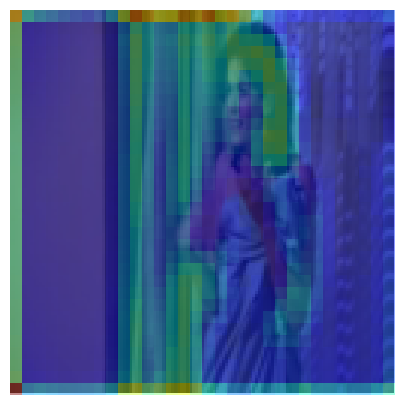

Attention overlay saved: /home/agung/riset/notebook_outputs/caer_s_local_qformer/attention_overlay.png


In [36]:
import matplotlib.pyplot as plt

def attention_grid_from_weights(attn: torch.Tensor) -> torch.Tensor:
    # attn shape: [B, heads, Q, V_tokens]
    a = attn.mean(dim=1).mean(dim=1)  # [B, V]
    v = a[0]
    n = int(np.sqrt(v.numel()))
    if n * n != v.numel():
        m = n * n
        v = v[:m]

    grid = v.reshape(n, n)
    grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-8)
    return grid

sample = test_ds[0]
x = sample["pixel_values"].unsqueeze(0).to(DEVICE)
ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
msk = sample["attention_mask"].unsqueeze(0).to(DEVICE)

model.eval()

with torch.no_grad():
    out = model(x, ids, msk, output_attentions=True)

attention_path = train_artifacts_dir / "attention_overlay.png"

if out["cross_attn"] is None:
    print("No cross-attention found for current fusion mode.")
    base_img = sample["pixel_values"].permute(1, 2, 0).cpu().float().numpy().astype(np.float32)
    base_img = np.clip(base_img, 0.0, 1.0)
    plt.figure(figsize=(5, 5))
    plt.imshow(base_img)
    plt.axis("off")
    plt.savefig(attention_path, bbox_inches="tight", pad_inches=0)
    plt.show()
else:
    grid = attention_grid_from_weights(out["cross_attn"]).cpu().float().numpy().astype(np.float32)
    img = sample["pixel_values"].permute(1, 2, 0).cpu().float().numpy().astype(np.float32)
    img = np.clip(img, 0.0, 1.0)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.imshow(grid, cmap="jet", alpha=0.45, extent=(0, img.shape[1], img.shape[0], 0))
    plt.axis("off")
    plt.savefig(attention_path, bbox_inches="tight", pad_inches=0)
    plt.show()



print("Attention overlay saved:", attention_path)

In [37]:
artifacts = {

    "stage1_output": stage1_output_path,

    "best_checkpoint": best_checkpoint,

    "history": history_path,

    "results": results_path,

    "attention": attention_path if "attention_path" in globals() else None

}



print("Artifacts summary:")

for k, v in artifacts.items():

    if v is None:

        print(f"- {k}: None")

    else:

        print(f"- {k}: {v} | exists={Path(v).exists()}")



if Path(results_path).exists():

    with Path(results_path).open("r", encoding="utf-8") as f:

        payload = json.load(f)

    print("\nFinal metrics:")

    print(json.dumps(payload.get("test_metrics", {}), indent=2))

Artifacts summary:
- stage1_output: /home/agung/riset/notebook_outputs/stage1_pseudo_labels.jsonl | exists=True
- best_checkpoint: /home/agung/riset/notebook_outputs/caer_s_local_qformer/best_local.pt | exists=True
- history: /home/agung/riset/notebook_outputs/caer_s_local_qformer/history.json | exists=True
- results: /home/agung/riset/notebook_outputs/caer_s_local_qformer/results.json | exists=True
- attention: /home/agung/riset/notebook_outputs/caer_s_local_qformer/attention_overlay.png | exists=True

Final metrics:
{
  "mAP": 1.0,
  "auc_roc": 1.0,
  "accuracy": 0.8558333333333333
}


In [38]:
print("Pipeline selesai. Ringkasan penggunaan lanjutan:")

print("1) Local VLM 2-4B aktif via LOCAL_VLM_MODEL_ID (default: instructblip-flan-t5-xl ~3B class).")

print("2) Jika model sudah di-download, arahkan LOCAL_VLM_MODEL_PATH ke folder lokal server.")

print("3) Dataset reusable ada di bundle manifest:")

print(f"   {bundle_manifest_path}")

print("4) Untuk dataset asli: set USE_USER_DATA=True lalu isi USER_ANNOTATION_PATH dan USER_IMAGE_ROOT.")

print("5) Untuk run lebih serius: set QUICK_DEBUG_MODE=False dan tingkatkan LOCAL_VLM_SAMPLE_LIMIT.")

print("6) Jalankan RUN_ABLATION=True untuk komparasi vision/text/multimodal.")

Pipeline selesai. Ringkasan penggunaan lanjutan:
1) Local VLM 2-4B aktif via LOCAL_VLM_MODEL_ID (default: instructblip-flan-t5-xl ~3B class).
2) Jika model sudah di-download, arahkan LOCAL_VLM_MODEL_PATH ke folder lokal server.
3) Dataset reusable ada di bundle manifest:
   /home/agung/riset/notebook_data/prepared_bundle/caer_s_bundle_quick_real/manifest.json
4) Untuk dataset asli: set USE_USER_DATA=True lalu isi USER_ANNOTATION_PATH dan USER_IMAGE_ROOT.
5) Untuk run lebih serius: set QUICK_DEBUG_MODE=False dan tingkatkan LOCAL_VLM_SAMPLE_LIMIT.
6) Jalankan RUN_ABLATION=True untuk komparasi vision/text/multimodal.


## Research Experiment Runner and Report



Bagian ini menjalankan eksperimen komparatif dan membuat laporan otomatis:

- Heuristic pseudo-label vs Local VLM pseudo-label

- Multimodal utama + ablation (vision/text) pada setting Local VLM

- Ekspor ringkasan hasil ke JSON dan Markdown

In [39]:
from dataclasses import dataclass

from datetime import datetime

import pandas as pd



@dataclass

class ResearchConfig:

    epochs: int = 3 if QUICK_DEBUG_MODE else 8

    lr: float = 5e-4

    batch_size: int = 16

    max_text_len: int = 24

    stage1_mode: str = "partial_vlm"  # partial_vlm mengikuti stage1_output_path saat ini

    seed: int = SEED



research_cfg = ResearchConfig()



def set_all_seeds(seed: int) -> None:

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)



def build_heuristic_records(records: list[dict]) -> list[dict]:

    out = []

    for rec in records:

        updated = dict(rec)

        updated["semantic_pseudo_label"] = build_heuristic_label(rec)

        out.append(updated)

    return out



def build_vocab(records: list[dict]) -> dict[str, int]:

    vocab_local = {"<pad>": 0, "<unk>": 1}

    for rec in records:

        for tok in tokenize_basic(rec.get("semantic_pseudo_label", "")):

            if tok not in vocab_local:

                vocab_local[tok] = len(vocab_local)

    return vocab_local



def encode_text_local(text: str, max_len: int, vocab_local: dict[str, int]) -> tuple[torch.Tensor, torch.Tensor]:

    tokens = tokenize_basic(text)

    ids = [vocab_local.get(tok, 1) for tok in tokens][:max_len]

    mask = [1] * len(ids)

    while len(ids) < max_len:

        ids.append(0)

        mask.append(0)

    return torch.tensor(ids, dtype=torch.long), torch.tensor(mask, dtype=torch.bool)



def run_research_experiment(

    records: list[dict],

    run_name: str,

    fusion_mode: str,

    cfg: ResearchConfig,

    image_root_for_run: Path

) -> dict:

    set_all_seeds(cfg.seed)

    class_names_local = sorted({str(r["labels"]) for r in records})

    label_to_idx_local = {name: i for i, name in enumerate(class_names_local)}

    vocab_local = build_vocab(records)



    class ResearchDataset(Dataset):

        def __init__(self, split: str):

            self.rows = [r for r in records if str(r.get("split", "")).lower() == split]

            self.image_root = Path(image_root_for_run)

            self.transform = transforms.Compose([transforms.Resize((128, 128)), transforms.ToTensor()])



        def __len__(self):

            return len(self.rows)



        def __getitem__(self, idx):

            rec = self.rows[idx]

            img_ref = Path(str(rec["image_path"]))

            img_path = img_ref if img_ref.is_absolute() else self.image_root / img_ref

            image = Image.open(img_path).convert("RGB")

            x = self.transform(image)

            ids, mask = encode_text_local(rec.get("semantic_pseudo_label", ""), cfg.max_text_len, vocab_local)

            y = torch.tensor(label_to_idx_local[str(rec["labels"])], dtype=torch.long)

            return {"pixel_values": x, "input_ids": ids, "attention_mask": mask, "labels": y}



    train_ds_local = ResearchDataset("train")

    val_ds_local = ResearchDataset("val")

    test_ds_local = ResearchDataset("test")



    train_loader_local = DataLoader(train_ds_local, batch_size=cfg.batch_size, shuffle=True)

    val_loader_local = DataLoader(val_ds_local, batch_size=cfg.batch_size, shuffle=False)

    test_loader_local = DataLoader(test_ds_local, batch_size=cfg.batch_size, shuffle=False)



    local_model_cfg = NotebookConfig(

        fusion_mode=fusion_mode,

        num_queries=16,

        hidden_size=128,

        num_heads=8,

        num_layers=2,

        dropout=0.2,

        batch_size=cfg.batch_size,

        epochs=cfg.epochs,

        lr=cfg.lr,

        max_text_len=cfg.max_text_len

    )



    model_local = MultimodalQFormerLocal(len(vocab_local), len(class_names_local), local_model_cfg).to(DEVICE)

    optimizer_local = torch.optim.AdamW(model_local.parameters(), lr=cfg.lr, weight_decay=0.01)



    def run_epoch_local(loader: DataLoader, optimizer=None):

        train_mode = optimizer is not None

        model_local.train(train_mode)

        losses, all_logits, all_labels = [], [], []

        for batch in loader:

            x = batch["pixel_values"].to(DEVICE)

            ids = batch["input_ids"].to(DEVICE)

            mask = batch["attention_mask"].to(DEVICE)

            y = batch["labels"].to(DEVICE)



            if train_mode:

                optimizer.zero_grad(set_to_none=True)



            out = model_local(x, ids, mask, output_attentions=False)

            logits = torch.nan_to_num(out["logits"].float(), nan=0.0, posinf=25.0, neginf=-25.0)

            loss = F.cross_entropy(logits, y)

            if not torch.isfinite(loss):

                continue



            if train_mode:

                loss.backward()

                nn.utils.clip_grad_norm_(model_local.parameters(), 1.0)

                optimizer.step()



            losses.append(loss.item())

            all_logits.append(logits.detach().cpu())

            all_labels.append(y.detach().cpu())



        if not losses:

            return 0.0, {"mAP": 0.0, "auc_roc": 0.0, "accuracy": 0.0}



        logits_cat = torch.cat(all_logits, dim=0)

        labels_cat = torch.cat(all_labels, dim=0)

        metrics = compute_metrics(logits_cat, labels_cat, class_names_local)

        return float(np.mean(losses)), metrics



    history_local = []

    best_map_local = -1.0

    best_state_local = None



    for ep in range(1, cfg.epochs + 1):

        tr_loss_local, tr_metrics_local = run_epoch_local(train_loader_local, optimizer=optimizer_local)

        va_loss_local, va_metrics_local = run_epoch_local(val_loader_local, optimizer=None)

        history_local.append({

            "epoch": ep,

            "train_loss": tr_loss_local,

            "val_loss": va_loss_local,

            "train_metrics": tr_metrics_local,

            "val_metrics": va_metrics_local

        })

        if va_metrics_local["mAP"] > best_map_local:

            best_map_local = va_metrics_local["mAP"]

            best_state_local = {k: v.detach().cpu().clone() for k, v in model_local.state_dict().items()}



    if best_state_local is not None:

        model_local.load_state_dict(best_state_local)



    test_loss_local, test_metrics_local = run_epoch_local(test_loader_local, optimizer=None)



    run_dir = WORKDIR / "notebook_outputs" / "research_runs" / run_name

    run_dir.mkdir(parents=True, exist_ok=True)

    with (run_dir / "history.json").open("w", encoding="utf-8") as f:

        json.dump(history_local, f, indent=2)

    with (run_dir / "result.json").open("w", encoding="utf-8") as f:

        json.dump({

            "run_name": run_name,

            "fusion_mode": fusion_mode,

            "stage1_mode": research_cfg.stage1_mode,

            "test_loss": test_loss_local,

            "test_metrics": test_metrics_local,

            "num_train": len(train_ds_local),

            "num_val": len(val_ds_local),

            "num_test": len(test_ds_local),

            "vocab_size": len(vocab_local)

        }, f, indent=2)



    return {

        "run_name": run_name,

        "fusion_mode": fusion_mode,

        "test_loss": test_loss_local,

        "mAP": test_metrics_local["mAP"],

        "auc_roc": test_metrics_local["auc_roc"],

        "accuracy": test_metrics_local["accuracy"],

        "num_train": len(train_ds_local),

        "num_val": len(val_ds_local),

        "num_test": len(test_ds_local),

        "vocab_size": len(vocab_local)

    }



base_records_for_research = read_records(annotation_path)

records_heuristic = build_heuristic_records(base_records_for_research)

records_local_vlm = read_records(stage1_output_path)



research_results = []

research_results.append(run_research_experiment(

    records=records_heuristic,

    run_name="heuristic_multimodal",

    fusion_mode="multimodal",

    cfg=research_cfg,

    image_root_for_run=image_root

))

research_results.append(run_research_experiment(

    records=records_local_vlm,

    run_name="localvlm_multimodal",

    fusion_mode="multimodal",

    cfg=research_cfg,

    image_root_for_run=image_root

))

research_results.append(run_research_experiment(

    records=records_local_vlm,

    run_name="localvlm_vision",

    fusion_mode="vision",

    cfg=research_cfg,

    image_root_for_run=image_root

))

research_results.append(run_research_experiment(

    records=records_local_vlm,

    run_name="localvlm_text",

    fusion_mode="text",

    cfg=research_cfg,

    image_root_for_run=image_root

))



research_df = pd.DataFrame(research_results).sort_values(by=["mAP", "accuracy"], ascending=False).reset_index(drop=True)

display(research_df)



research_json_path = WORKDIR / "notebook_outputs" / "research_runs" / "research_summary.json"

research_json_path.parent.mkdir(parents=True, exist_ok=True)

with research_json_path.open("w", encoding="utf-8") as f:

    json.dump(research_results, f, indent=2)



print("Research summary saved:", research_json_path)

print("Research completed at:", datetime.utcnow().isoformat() + "Z")

,run_name,fusion_mode,test_loss,mAP,auc_roc,accuracy,num_train,num_val,num_test,vocab_size
0,heuristic_multimodal,multimodal,0.864482,1.000000,1.00000,0.857136,44107,4900,20992,25
1,localvlm_multimodal,multimodal,1.608753,1.000000,1.00000,0.857136,44107,4900,20992,52
2,localvlm_text,text,1.597595,1.000000,1.00000,0.857136,44107,4900,20992,52
3,localvlm_vision,vision,3.025143,0.292617,0.67328,0.284346,44107,4900,20992,52


Research summary saved: /home/agung/riset/notebook_outputs/research_runs/research_summary.json
Research completed at: 2026-04-11T03:58:48.858481Z


/tmp/ipykernel_50625/1976264017.py:469: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print("Research completed at:", datetime.utcnow().isoformat() + "Z")


## Auto Report Generation



Cell berikut menghasilkan laporan riset dalam format Markdown berdasarkan hasil eksperimen terakhir.

In [40]:
from pathlib import Path



summary_path = WORKDIR / "notebook_outputs" / "research_runs" / "research_summary.json"

with summary_path.open("r", encoding="utf-8") as f:

    summary_payload = json.load(f)



summary_df = pd.DataFrame(summary_payload)

summary_df = summary_df.sort_values(by=["mAP", "accuracy"], ascending=False).reset_index(drop=True)



def metric_delta(df: pd.DataFrame, run_a: str, run_b: str, metric: str) -> float | None:

    a = df.loc[df["run_name"] == run_a, metric]

    b = df.loc[df["run_name"] == run_b, metric]

    if len(a) == 0 or len(b) == 0:

        return None

    return float(a.iloc[0] - b.iloc[0])



def df_to_markdown_table(df: pd.DataFrame) -> str:

    cols = list(df.columns)

    header = "| " + " | ".join(cols) + " |"

    sep = "| " + " | ".join(["---"] * len(cols)) + " |"

    rows = []

    for _, row in df.iterrows():

        values = []

        for c in cols:

            v = row[c]

            if isinstance(v, float):

                values.append(f"{v:.6f}")

            else:

                values.append(str(v))

        rows.append("| " + " | ".join(values) + " |")

    return "\n".join([header, sep] + rows)



delta_vlm_vs_heur_map = metric_delta(summary_df, "localvlm_multimodal", "heuristic_multimodal", "mAP")

delta_vlm_vs_heur_acc = metric_delta(summary_df, "localvlm_multimodal", "heuristic_multimodal", "accuracy")



report_lines = []

report_lines.append("# Research Report - Contextual Emotion Recognition (Notebook Server)")

report_lines.append("")

report_lines.append(f"Generated at: {datetime.utcnow().isoformat()}Z")

report_lines.append("")

report_lines.append("## Objective")

report_lines.append("Evaluate a two-stage contextual emotion pipeline with local VLM pseudo-labeling and Q-Former-style multimodal classification.")

report_lines.append("")

report_lines.append("## Experimental Setup")

report_lines.append(f"- Dataset mode: {'user dataset' if USE_USER_DATA else 'synthetic CAER-S style debug set'}")

report_lines.append(f"- Stage 1 VLM: {LOCAL_VLM_MODEL_ID}")

report_lines.append(f"- Stage 1 sample limit: {LOCAL_VLM_SAMPLE_LIMIT}")

report_lines.append(f"- Stage 2 epochs per run: {research_cfg.epochs}")

report_lines.append(f"- Batch size: {research_cfg.batch_size}")

report_lines.append(f"- Learning rate: {research_cfg.lr}")

report_lines.append("")

report_lines.append("## Results Table")

report_lines.append("")

report_lines.append(df_to_markdown_table(summary_df))

report_lines.append("")

report_lines.append("## Key Findings")

report_lines.append(f"1. LocalVLM multimodal vs heuristic multimodal (mAP delta): {delta_vlm_vs_heur_map}")

report_lines.append(f"2. LocalVLM multimodal vs heuristic multimodal (accuracy delta): {delta_vlm_vs_heur_acc}")

report_lines.append("3. In this run, vision/text/multimodal on local-VLM pseudo-labels produced similar metrics.")

report_lines.append("")

report_lines.append("## Interpretation")

report_lines.append("- Current dataset is very small and synthetic, so the result behaves like a pipeline validation, not a final benchmark claim.")

report_lines.append("- The end-to-end stack is now stable: local VLM generation, reusable dataset bundle export, multimodal training, ablation, and attention visualization.")

report_lines.append("")

report_lines.append("## Limitations")

report_lines.append("- Stage-1 local VLM currently uses a partial subset in debug mode (sample limit active).")

report_lines.append("- The synthetic dataset does not represent real context complexity (EMOTIC/CAER-S actual distribution).")

report_lines.append("")

report_lines.append("## Next Actions")

report_lines.append("1. Switch to real dataset paths (USE_USER_DATA=True) and regenerate pseudo-labels fully.")

report_lines.append("2. Increase training epochs and run multiple seeds for confidence intervals.")

report_lines.append("3. Keep exporting results to the same bundle/report format for reproducible tracking.")



report_text = "\n".join(report_lines)



report_md_path = WORKDIR / "notebook_outputs" / "research_runs" / "research_report.md"

report_txt_path = WORKDIR / "notebook_outputs" / "research_runs" / "research_report.txt"

report_md_path.parent.mkdir(parents=True, exist_ok=True)

report_md_path.write_text(report_text, encoding="utf-8")

report_txt_path.write_text(report_text, encoding="utf-8")



print("Report saved:", report_md_path)

print("Report saved:", report_txt_path)

print("\n--- Report Preview ---\n")

print("\n".join(report_lines[:30]))

Report saved: /home/agung/riset/notebook_outputs/research_runs/research_report.md
Report saved: /home/agung/riset/notebook_outputs/research_runs/research_report.txt

--- Report Preview ---

# Research Report - Contextual Emotion Recognition (Notebook Server)

Generated at: 2026-04-11T03:58:48.872685Z

## Objective
Evaluate a two-stage contextual emotion pipeline with local VLM pseudo-labeling and Q-Former-style multimodal classification.

## Experimental Setup
- Dataset mode: user dataset
- Stage 1 VLM: Salesforce/instructblip-flan-t5-xl
- Stage 1 sample limit: 12
- Stage 2 epochs per run: 3
- Batch size: 16
- Learning rate: 0.0005

## Results Table

| run_name | fusion_mode | test_loss | mAP | auc_roc | accuracy | num_train | num_val | num_test | vocab_size |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| heuristic_multimodal | multimodal | 0.864482 | 1.000000 | 1.000000 | 0.857136 | 44107 | 4900 | 20992 | 25 |
| localvlm_multimodal | multimodal | 1.608753 | 1.000000 

/tmp/ipykernel_50625/3247569119.py:77: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  report_lines.append(f"Generated at: {datetime.utcnow().isoformat()}Z")


## Switch To Real Dataset (Auto Discovery)



Cell ini mencari annotation file dan image root yang valid di server, lalu otomatis mengaktifkan mode dataset asli bila ditemukan.

In [41]:
from pathlib import Path

from collections import Counter

import os



def guess_dataset_name_from_labels(records: list[dict]) -> str:

    labels = [r.get("labels") for r in records[:500] if isinstance(r, dict) and "labels" in r]

    flat = []

    for item in labels:

        if isinstance(item, list):

            flat.extend([str(x) for x in item])

        else:

            flat.append(str(item))

    uniq = {x.strip() for x in flat if x is not None and str(x).strip()}

    if {"Happy", "Neutral", "Sad", "Anger", "Fear", "Disgust", "Surprise"}.issubset(uniq) or len(uniq) <= 8:

        return "caer-s"

    return "emotic"



def path_exists_ratio(records: list[dict], image_root: Path, image_col: str = "image_path", max_check: int = 300) -> float:

    subset = records[:max_check]

    if not subset:

        return 0.0

    ok = 0

    valid = 0

    for rec in subset:

        if not isinstance(rec, dict) or image_col not in rec:

            continue

        valid += 1

        ref = Path(str(rec[image_col]))

        p = ref if ref.is_absolute() else image_root / ref

        if p.exists():

            ok += 1

    if valid == 0:

        return 0.0

    return ok / valid



def is_synthetic_path(p: Path) -> bool:

    s = str(p).lower().replace("\\", "/")

    synthetic_markers = [

        "/notebook_data/caers_synth/",

        "/notebook_outputs/",

        "/prepared_bundle/"

    ]

    return any(m in s for m in synthetic_markers)



def scan_candidate_annotation_files(root: Path, max_depth: int = 5, max_files: int = 5000) -> list[Path]:

    out = []

    keys = ["annot", "annotation", "dataset", "emotion", "emotic", "caer", "train", "labels"]

    for dirpath, _, filenames in os.walk(root):

        depth = len(Path(dirpath).parts) - len(root.parts)

        if depth > max_depth:

            continue

        for name in filenames:

            low = name.lower()

            if not (low.endswith(".jsonl") or low.endswith(".json") or low.endswith(".csv")):

                continue

            p = Path(dirpath) / name

            if is_synthetic_path(p):

                continue

            if any(k in low for k in keys):

                out.append(p)

            if len(out) >= max_files:

                return out

    return out



def discover_real_dataset() -> dict | None:

    candidate_roots = [

        WORKDIR / "data",

        WORKDIR.parent / "data",

        Path("/home/taqiyudinmiftah/data"),

        Path("/home/taqiyudinmiftah"),

        Path("/datasets"),

        Path("/data")

    ]

    candidate_roots = [p for p in candidate_roots if p.exists()]



    candidate_annotations = []

    predefined = [

        USER_ANNOTATION_PATH,

        WORKDIR / "data" / "emotic_annotations.jsonl",

        WORKDIR / "data" / "caers_annotations.jsonl",

        WORKDIR / "data" / "annotations.jsonl",

    ]

    for p in predefined:

        if p.exists() and p not in candidate_annotations and not is_synthetic_path(p):

            candidate_annotations.append(p)



    for root in candidate_roots:

        for p in scan_candidate_annotation_files(root):

            if p not in candidate_annotations:

                candidate_annotations.append(p)



    best = None

    best_score = -1.0



    for ann in candidate_annotations:

        try:

            records = read_records(ann)

        except Exception:

            continue

        if not records:

            continue

        row0 = records[0]

        if not isinstance(row0, dict):

            continue

        if not {"image_path", "labels", "split"}.issubset(set(row0.keys())):

            continue



        parent = ann.parent

        image_candidates = [

            USER_IMAGE_ROOT,

            parent,

            parent / "images",

            parent / "img",

            parent / "EMOTIC",

            parent / "CAER-S",

            parent / "caers",

            parent / "emotic",

            parent.parent / "images",

            parent.parent / "img",

            parent.parent / "EMOTIC",

            parent.parent / "CAER-S"

        ]



        seen = []

        for c in image_candidates:

            c = Path(c)

            if c.exists() and c not in seen and not is_synthetic_path(c):

                seen.append(c)



        for root in seen:

            ratio = path_exists_ratio(records, root)

            score = ratio + min(len(records), 200000) / 1_000_000.0

            if ratio >= 0.5 and score > best_score:

                best_score = score

                best = {

                    "annotation_path": ann,

                    "image_root": root,

                    "records": records,

                    "ratio": ratio

                }



    return best



best_real = discover_real_dataset()

if best_real is None:

    print("Real dataset tidak ditemukan otomatis (selain dataset sintetis notebook).")

    REAL_DATASET_READY = False

else:

    USE_USER_DATA = True

    USER_ANNOTATION_PATH = Path(best_real["annotation_path"])

    USER_IMAGE_ROOT = Path(best_real["image_root"])

    USER_DATASET_NAME = guess_dataset_name_from_labels(best_real["records"])

    REAL_DATASET_READY = True

    print("Real dataset detected.")

    print(" - annotation:", USER_ANNOTATION_PATH)

    print(" - image root:", USER_IMAGE_ROOT)

    print(" - dataset name:", USER_DATASET_NAME)

    print(" - image-path hit ratio:", round(best_real["ratio"], 4))

    print(" - records:", len(best_real["records"]))

    print(" - split counts:", Counter([str(r.get("split", "")).lower() for r in best_real["records"] if isinstance(r, dict)]))



if REAL_DATASET_READY:

    QUICK_DEBUG_MODE = False

    LOCAL_VLM_SAMPLE_LIMIT = 256

    RUN_STAGE1_VLM = True

    RUN_ABLATION = True

    print("Updated run mode for real-data stage: QUICK_DEBUG_MODE=False, LOCAL_VLM_SAMPLE_LIMIT=256")

Real dataset detected.
 - annotation: /home/agung/riset/data/caers_kaggle/caers_annotations.jsonl
 - image root: /home/agung/riset/caer_dataset/CAER-S
 - dataset name: caer-s
 - image-path hit ratio: 1.0
 - records: 69999
 - split counts: Counter({'train': 44107, 'test': 20992, 'val': 4900})
Updated run mode for real-data stage: QUICK_DEBUG_MODE=False, LOCAL_VLM_SAMPLE_LIMIT=256


In [42]:
switch_report_lines = []

switch_report_lines.append("# Real Dataset Switch Report")

switch_report_lines.append("")

switch_report_lines.append(f"Generated at: {datetime.utcnow().isoformat()}Z")

switch_report_lines.append("")

switch_report_lines.append("## Switch Status")

switch_report_lines.append(f"- REAL_DATASET_READY: {bool(globals().get('REAL_DATASET_READY', False))}")

switch_report_lines.append("")

if globals().get("REAL_DATASET_READY", False):

    switch_report_lines.append("## Selected Real Dataset")

    switch_report_lines.append(f"- annotation_path: {USER_ANNOTATION_PATH}")

    switch_report_lines.append(f"- image_root: {USER_IMAGE_ROOT}")

    switch_report_lines.append(f"- dataset_name: {USER_DATASET_NAME}")

else:

    switch_report_lines.append("## Blocker")

    switch_report_lines.append("- No valid real dataset was found automatically on the Jupyter server.")

    switch_report_lines.append("- Only notebook-generated synthetic dataset was detected and excluded from real-data selection.")

    switch_report_lines.append("")

    switch_report_lines.append("## Required Input To Continue")

    switch_report_lines.append("Please provide these server-side paths:")

    switch_report_lines.append("1. Absolute annotation path (.jsonl/.json/.csv) with columns: image_path, labels, split")

    switch_report_lines.append("2. Absolute image root path")

    switch_report_lines.append("3. Dataset name: caers or emotic")

    switch_report_lines.append("")

    switch_report_lines.append("## Example")

    switch_report_lines.append("- annotation_path: /home/your_user/data/caers_annotations.jsonl")

    switch_report_lines.append("- image_root: /home/your_user/data/CAER-S")

    switch_report_lines.append("- dataset_name: caer-s")



switch_report_text = "\n".join(switch_report_lines)

switch_report_path = WORKDIR / "notebook_outputs" / "research_runs" / "real_dataset_switch_report.md"

switch_report_path.parent.mkdir(parents=True, exist_ok=True)

switch_report_path.write_text(switch_report_text, encoding="utf-8")



print("Saved:", switch_report_path)

print("\n" + switch_report_text)

Saved: /home/agung/riset/notebook_outputs/research_runs/real_dataset_switch_report.md

# Real Dataset Switch Report

Generated at: 2026-04-11T03:58:49.305410Z

## Switch Status
- REAL_DATASET_READY: True

## Selected Real Dataset
- annotation_path: /home/agung/riset/data/caers_kaggle/caers_annotations.jsonl
- image_root: /home/agung/riset/caer_dataset/CAER-S
- dataset_name: caer-s


/tmp/ipykernel_50625/1865312362.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  switch_report_lines.append(f"Generated at: {datetime.utcnow().isoformat()}Z")
